<div class="dark-title" style="background:linear-gradient(90deg,#1e3a8a,#5b21b6); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🏗️ Building Agents — 搭一个 email assistant

**一句话定位**:从零开始搭出 **router(workflow)+ response agent(子图)** 的混合架构,这是后续 4 节课的地基。

</div>

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**📚 提示**:学这节课前,建议先看 [这些 slides](https://docs.google.com/presentation/d/13c0L1CQWAL7fuCXakOqjkvoodfynPJI4Hw_4H76okVU/edit?usp=sharing) 和 [langgraph_101.ipynb](langgraph_101.ipynb)。

**🎯 整门课的脉络**(从这节开始,环环相扣):

1. **本节**:搭 agent 架构(用 [LangGraph](https://langchain-ai.github.io/langgraph/))
2. **下一节**:测试它(用 [LangSmith](https://docs.smith.langchain.com/))
3. **再下节**:加 human-in-the-loop
4. **最后**:加 memory

各模块的拼装关系如下图:

</div>

![overview-img](img/overview.png)

#### 🔐 加载环境变量

In [1]:
from dotenv import load_dotenv

load_dotenv(override=True)

True

## 🔧 工具定义(Tool Definition)

先用 `@tool` 装饰器定义几个 email assistant 要用的简单工具:

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**4 个工具的角色分工**

| 工具 | 类型 | 干嘛 |
|------|------|------|
| `write_email` | **副作用型** | 发邮件(本课是 mock,生产里换 Gmail API) |
| `schedule_meeting` | **副作用型** | 安排会议 |
| `check_calendar_availability` | **查询型** | 查日历可用时间段 |
| `Done`(class!) | **信号型** | LLM 调它 = 任务完成,触发循环退出 |

📎 工具类型详见 [`0_c_⭐️_工具类型大全.ipynb`](./0_c_⭐️_工具类型大全.ipynb)

</div>

In [ ]:
from typing import Literal
from datetime import datetime
from pydantic import BaseModel
from langchain_core.tools import tool


@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"


@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"


@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"


@tool
class Done(BaseModel):
    """E-mail has been sent."""

    done: bool

## 🛠️ 搭 email assistant —— 整体架构

我们把 [router 和 agent](https://langchain-ai.github.io/langgraph/tutorials/workflows/) **组合** 起来搭这个 email assistant:

![agent_workflow_img](img/email_workflow.png)

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**💎 核心设计:workflow 包 agent**

- **外层 workflow**:三选一 triage(respond / notify / ignore)—— 流程在白板能画清,**用 workflow 写死**
- **内层 agent**:回信怎么写、要不要查日历、要不要约会 —— 运行时才知道,**留给 agent 自由发挥**

这就是 Lance 反复强调的「**能画清就用 workflow,开放部分留给 agent**」的实践。

</div>

### 🔀 Router 部分

triage router **只管分类**,response agent **只管回信** —— 职责分离。

### 📦 State —— 整个图共享的「记忆」

我们用 LangGraph 预制的 [`MessagesState`](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate) 作为基础——它内置一个 `messages` key,带 [`add_messages` reducer](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers),节点返回的消息会自动 **追加**(不是覆盖)。

但 LangGraph 允许我们 **扩展** state 加任何字段。这里我们继承 `MessagesState`,加两个新 key:

| 字段 | 类型 | 作用 |
|------|------|------|
| `messages` | `List[BaseMessage]` | 继承自 `MessagesState`,append 累积 |
| `email_input` | `dict` | 入站邮件(发件人、主题、正文) |
| `classification_decision` | `Literal["ignore","respond","notify"]` | triage router 分类的结果 |

In [ ]:
from langgraph.graph import MessagesState


class State(MessagesState):
    # We can add a specific key to our state for the email input
    email_input: dict
    classification_decision: Literal["ignore", "respond", "notify"]

#### 🎯 Triage 节点 —— 用 Structured Output 做分类

定义一个 Python 函数实现 triage 路由逻辑。

这里用 [structured outputs](https://python.langchain.com/docs/concepts/structured_outputs/) + **Pydantic 模型** —— 它特别适合定义输出 schema:

- 提供 **类型提示** 和 **运行时校验**
- Field 的 `description` **会被传给 LLM**,告诉它每个字段是什么意思,帮助它正确生成

<div class="dark-orange" style="background:#2d2418; color:#fed7aa; padding:10px 24px; border-left:4px solid #fb923c; border-radius:4px; width:97%;"><style>.dark-orange strong{color:#67e8f9;}</style>

💡 **关键技巧**:`.with_structured_output(YourPydanticModel)` 让 LLM 输出 **强制符合 schema 的对象** —— 这是 router 类节点最稳妥的设计。LLM 不会"乱回字符串",而是返回 `YourPydanticModel` 实例,可以直接 `.classification` 取值。

</div>

In [4]:

%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../src")
from pydantic import BaseModel, Field
from email_assistant.utils import parse_email, format_email_markdown
from email_assistant.prompts import triage_system_prompt, triage_user_prompt, default_triage_instructions, default_background
from langchain.chat_models import init_chat_model
from langgraph.graph import END
from langgraph.types import Command

In [5]:
from rich.markdown import Markdown

Markdown(triage_system_prompt)

< Role > Your role is to triage incoming emails based upon instructs and background information below. </ Role >   

< Background > {background}. </ Background >                                                                       

< Instructions > Categorize each email into one of three categories:                                               

 1 IGNORE - Emails that are not worth responding to or tracking                                                    
 2 NOTIFY - Important information that worth notification but doesn't require a response                           
 3 RESPOND - Emails that need a direct response Classify the below email into one of these categories. </          
   Instructions >                                                                                                  

< Rules > {triage_instructions} </ Rules >

In [6]:
Markdown(triage_user_prompt)

Please determine how to handle the below email thread:                                                             

From: {author} To: {to} Subject: {subject} {email_thread}

In [7]:
Markdown(default_background)

I'm Lance, a software engineer at LangChain.

In [8]:
Markdown(default_triage_instructions)

Emails that are not worth responding to:                                                                           

 • Marketing newsletters and promotional emails                                                                    
 • Spam or suspicious emails                                                                                       
 • CC'd on FYI threads with no direct questions                                                                    

There are also other things that should be known about, but don't require an email response. For these, you should 
notify (using the notify response). Examples of this include:                                                      

 • Team member out sick or on vacation                                                                             
 • Build system notifications or deployments                                                                       
 • Project status updates without action items                                                                     
 • Important company announcements                                                                                 
 • FYI emails that contain relevant information for current projects                                               
 • HR Department deadline reminders                                                                                
 • Subscription status / renewal reminders                                                                         
 • GitHub notifications                                                                                            

Emails that are worth responding to:                                                                               

 • Direct questions from team members requiring expertise                                                          
 • Meeting requests requiring confirmation                                                                         
 • Critical bug reports related to team's projects                                                                 
 • Requests from management requiring acknowledgment                                                               
 • Client inquiries about project status or features                                                               
 • Technical questions about documentation, code, or APIs (especially questions about missing endpoints or         
   features)                                                                                                       
 • Personal reminders related to family (wife / daughter)                                                          
 • Personal reminder related to self-care (doctor appointments, etc)

In [9]:
class RouterSchema(BaseModel):
    """Analyze the unread email and route it according to its content."""

    reasoning: str = Field(description="Step-by-step reasoning behind the classification.")
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )


# Initialize the LLM for use with router / structured output
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_router = llm.with_structured_output(RouterSchema)


def triage_router(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """Analyze email content to decide if we should respond, notify, or ignore."""

    author, to, subject, email_thread = parse_email(state["email_input"])
    system_prompt = triage_system_prompt.format(
        background=default_background, triage_instructions=default_triage_instructions
    )

    user_prompt = triage_user_prompt.format(author=author, to=to, subject=subject, email_thread=email_thread)

    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )

    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email: \n\n{format_email_markdown(subject, author, to, email_thread)}",
                }
            ],
            "classification_decision": result.classification,
        }

    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        goto = END
        update = {
            "classification_decision": result.classification,
        }

    elif result.classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information")
        # For now, we go to END. But we will add to this later!
        goto = END
        update = {
            "classification_decision": result.classification,
        }

    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 这一行的精髓**

我们用 [`Command`](https://langchain-ai.github.io/langgraph/how-tos/command/) 对象 **同时做两件事**:

1. `update={...}` —— 更新 state(写入 classification_decision、给子图喂消息)
2. `goto="response_agent"` —— 决定下一个 node

这是 conditional edges 的 **强力替代品**——本来需要「节点写 state → conditional edge 读 state 决定路由」三步,`Command` **压成一步**。

📎 详见 [`0_b_⭐️_edges_vs_Command.ipynb`](./0_b_⭐️_edges_vs_Command.ipynb)

</div>

## 🤖 Agent 部分

现在开始搭 agent 子图。

### 🧠 LLM Node —— 决策节点

定义 agent 的 **大脑节点**:接收当前 state,调 LLM,把 LLM 输出追加进 `messages`。

我们用 [`tool_choice="any"`](https://python.langchain.com/docs/how_to/tool_choice/) **强制 LLM 至少调一个工具**(OpenAI 文档里叫 `tool_choice="required"`)—— 否则 LLM 可能输出纯文本,后续的 `should_continue` 边访问空 `tool_calls` 就会报错。

In [10]:
import sys
sys.path.append("../src")
from email_assistant.tools.default.prompt_templates import AGENT_TOOLS_PROMPT
from email_assistant.prompts import agent_system_prompt, default_response_preferences, default_cal_preferences

In [11]:
Markdown(AGENT_TOOLS_PROMPT)

 1 write_email(to, subject, content) - Send emails to specified recipients                                         
 2 schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings  
   where preferred_day is a datetime object                                                                        
 3 check_calendar_availability(day) - Check available time slots for a given day                                   
 4 Done - E-mail has been sent

In [12]:
Markdown(agent_system_prompt)

< Role > You are a top-notch executive assistant who cares about helping your executive perform as well as         
possible. </ Role >                                                                                                

< Tools > You have access to the following tools to help manage communications and schedule: {tools_prompt} </     
Tools >                                                                                                            

< Instructions > When handling emails, follow these steps:                                                         

 1 Carefully analyze the email content and purpose                                                                 
 2 IMPORTANT --- always call a tool and call one tool at a time until the task is complete:                        
 3 For responding to the email, draft a response email with the write_email tool                                   
 4 For meeting requests, use the check_calendar_availability tool to find open time slots                          
 5 To schedule a meeting, use the schedule_meeting tool with a datetime object for the preferred_day parameter     
    • Today's date is 2026-05-17 - use this for scheduling meetings accurately                                     
 6 If you scheduled a meeting, then draft a short response email using the write_email tool                        
 7 After using the write_email tool, the task is complete                                                          
 8 If you have sent the email, then use the Done tool to indicate that the task is complete </ Instructions >      

< Background > {background} </ Background >                                                                        

< Response Preferences > {response_preferences} </ Response Preferences >                                          

< Calendar Preferences > {cal_preferences} </ Calendar Preferences >

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 为什么 `Done` 用 class,而不是 function?**

因为 **信号型工具** 的全部价值 = 「LLM 调了它」这个事件本身。

- 没有副作用要执行
- 没有数据要返回
- 唯一意义是 **让条件边知道「LLM 觉得做完了」**

→ Pydantic class 比 `@tool` function **更优雅**,意图更明显:**只给 LLM 看 schema,不需要执行代码**。

📎 完整工具类型分类详见 [`0_c_⭐️_工具类型大全.ipynb`](./0_c_⭐️_工具类型大全.ipynb)

</div>

In [13]:
# Collect all tools
tools = [write_email, schedule_meeting, check_calendar_availability, Done]
tools_by_name = {tool.name: tool for tool in tools}

# Initialize the LLM, enforcing tool use
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_with_tools = llm.bind_tools(tools, tool_choice="any")


def llm_call(state: State):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            # Invoke the LLM
            llm_with_tools.invoke(
                # Add the system prompt
                [
                    {
                        "role": "system",
                        "content": agent_system_prompt.format(
                            tools_prompt=AGENT_TOOLS_PROMPT,
                            background=default_background,
                            response_preferences=default_response_preferences,
                            cal_preferences=default_cal_preferences,
                        ),
                    }
                ]
                # Add the current messages to the prompt
                + state["messages"]
            )
        ]
    }

### 🛠️ Tool Handler 节点 —— 执行器

LLM 决策完调哪个工具后,**真正执行** 工具的是 `tool_handler` 节点。

它做的事:

1. 从最新的 `AIMessage` 里取出所有 `tool_calls`
2. 用 `tool_call["name"]` 查到对应的工具
3. 用 `tool_call["args"]` 实际调用工具
4. 把结果包成 `ToolMessage`,**追加** 进 state

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

💡 **可以更新 state 的任意字段**

虽然这里只追加 messages,但 node 是可以**同时更新多个 state 字段**的(比如同时改 classification_decision)。这种灵活性在后面 HITL 和 memory 章节会被充分利用。

</div>

In [14]:
def tool_handler(state: State):
    """Performs the tool call."""

    # List for tool messages
    result = []

    # Iterate through tool calls
    for tool_call in state["messages"][-1].tool_calls:
        # Get the tool
        tool = tools_by_name[tool_call["name"]]
        # Run it
        observation = tool.invoke(tool_call["args"])
        # Create a tool message
        result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})

    # Add it to our messages
    return {"messages": result}

### 🔀 Conditional Routing —— 循环何时停?

Agent 需要判断:**继续调工具,还是停下来**?这就是条件边的工作。

我们的设计:**当 LLM 调了 `Done` 工具,就停**;否则去 `tool_handler` 继续。

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 `Done` 工具的运行时配合**

`Done` 是 Pydantic class,**没有执行体**。`tool_handler` 即便对它 `.invoke(...)` 也基本是 no-op。

真正让循环停下来的,是 **条件边里的字符串匹配**:`if tc["name"] == "Done": return END`。

→ 这就是「LLM 表达意图(调 Done)」+ 「条件边消费意图(检测名字)」的对偶。

</div>

In [15]:
def should_continue(state: State) -> Literal["tool_handler", "__end__"]:
    """Route to tool handler, or end if Done tool called."""

    # Get the last message
    messages = state["messages"]
    last_message = messages[-1]

    # Check if it's a Done tool call
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls:
            if tool_call["name"] == "Done":
                return END
            else:
                return "tool_handler"

### 🧩 Agent Graph —— 组装!

把所有组件拼起来:

In [16]:
from langgraph.graph import StateGraph, START, END
from email_assistant.utils import show_graph

# Build workflow
overall_workflow = StateGraph(State)

# Add nodes
overall_workflow.add_node("llm_call", llm_call)
overall_workflow.add_node("tool_handler", tool_handler)

# Add edges
overall_workflow.add_edge(START, "llm_call")
overall_workflow.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_handler": "tool_handler",
        END: END,
    },
)
overall_workflow.add_edge("tool_handler", "llm_call")

# Compile the agent
agent = overall_workflow.compile()

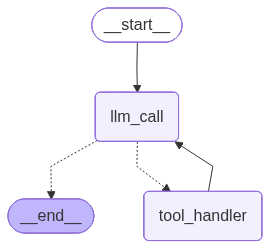

In [17]:
# View
show_graph(agent)

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🎬 这个 graph 干了什么**

1. **起点**:LLM 决策(调哪个工具)
2. **条件路由**:跳到工具执行节点 / 终止
3. **工具执行完**:回到 LLM,继续下一步决策
4. **循环**:直到 LLM 调 `Done`(或不再调工具)

这就是 **ReAct 循环** 的手搓版,跟 `create_react_agent` 内部做的事是一回事。

</div>

## 🔗 把 workflow 和 agent 组合起来

LangGraph 最强的能力之一:**子图直接当 node 用**。

`agent_workflow.compile()` 返回的 `agent` 对象,**本身就是个 graph**,但它也满足 LangGraph 的 node 接口(吃 state,返回 state 更新)。所以可以直接 `add_node("response_agent", agent)` 嵌进外层图。

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**🎁 这是 LangGraph 的「递归组合性」**

同一套 「nodes + edges + state」原语,既能搭单个 agent,也能搭 agent 之上的 workflow,**层数想加多深都行**(在后面 deep agents 课程里你会看到 agent 派单给子 agent 的更复杂模式)。

</div>

In [18]:
overall_workflow = (
    StateGraph(State).add_node(triage_router).add_node("response_agent", agent).add_edge(START, "triage_router")
).compile()

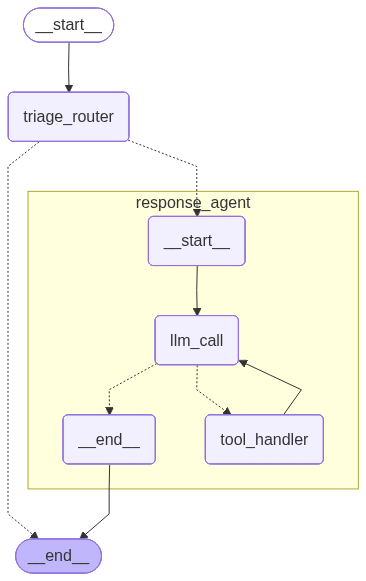

In [19]:
show_graph(overall_workflow, xray=True)

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🎯 这个高层 graph 的执行流**

1. **第一步**:triage router 分析邮件
2. **若需要回信**:response agent 接管,生成回信
3. **结束**:要么 triage 决定不回(notify/ignore),要么 response agent 写完

</div>

In [20]:
email_input = {
    "author": "System Admin <sysadmin@company.com>",
    "to": "Development Team <dev@company.com>",
    "subject": "Scheduled maintenance - database downtime",
    "email_thread": "Hi team,\n\nThis is a reminder that we'll be performing scheduled maintenance on the production database tonight from 2AM to 4AM EST. During this time, all database services will be unavailable.\n\nPlease plan your work accordingly and ensure no critical deployments are scheduled during this window.\n\nThanks,\nSystem Admin Team",
}

# Run the agent
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

🔔 Classification: NOTIFY - This email contains important information


In [21]:
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": "Hi John,\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\nThanks!\nAlice",
}

# Run the agent
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

📧 Classification: RESPOND - This email requires a response
================================ Human Message =================================

Respond to the email: 



**Subject**: Quick question about API documentation
**From**: Alice Smith <alice.smith@company.com>
**To**: John Doe <john.doe@company.com>

Hi John,
I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?
Specifically, I'm looking at:
- /auth/refresh
- /auth/validate
Thanks!
Alice

---

================================== Ai Message ==================================
Tool Calls:
  write_email (call_wZuXje93Q8AT2Os2chrOSk26)
 Call ID: call_wZuXje93Q8AT2Os2chrOSk26
  Args:
    to: alice.smith@company.com
    subject: Re: Quick question about API documentation
    content: Hi Alice,

Thank you for bringing this to my attention. I'll investigate whether the /auth/refre

## 🧪 用本地部署测试

agent 的源码在 `src/email_assistant/` 目录:

- `src/email_assistant/email_assistant.py`

可以在 LangGraph Studio 里测试:

```bash
! langgraph dev
```

<div class="dark-orange" style="background:#2d2418; color:#fed7aa; padding:10px 24px; border-left:4px solid #fb923c; border-radius:4px; width:97%;"><style>.dark-orange strong{color:#67e8f9;}</style>

💡 **跑命令的位置很重要**

`langgraph dev` 必须在 **`langgraph.json` 所在的目录** 跑(本仓库是 `project-002-ambiant-agents/`)。在 src/ 子目录里跑会报「Path 'langgraph.json' does not exist」。

如果你用 `uv` 管理依赖,推荐:`uv run langgraph dev`(自动用项目 venv)。

</div>

**可以测试的邮件示例**:

In [ ]:
{
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": "Hi John,\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\nThanks!\nAlice",
}

![studio-img](img/studio.png)

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

## ✨ 本节带走

**Build 的核心范式 = workflow 包 agent**:

- **能画清的部分**(三选一 triage)→ workflow 写死,用 `Command(goto, update)` 一行同时跳转 + 喂消息
- **开放的部分**(怎么回信)→ agent 自由发挥,用 `bind_tools` + 条件边检测 `Done` 信号终止
- **嵌套用**:子图 `.compile()` 后直接 `add_node("name", agent)`,层级递归没限制

🎯 **下一步**:用 [`2_evaluation.ipynb`](./2_evaluation.ipynb) 学怎么测它。

📎 配套精华笔记:[`1_z_⭐️_本节精华_Build.ipynb`](./1_z_⭐️_本节精华_Build.ipynb)

</div>